In [0]:
import warnings
from matplotlib import pyplot as plt
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import VectorAssembler
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, ascii, when

warnings.filterwarnings('ignore')

In [0]:
spark = SparkSession.builder.appName('Mushroom Logistics 2').getOrCreate()

In [0]:
df = spark.read.csv("mushrooms.csv", header = True, inferSchema = True)

In [0]:
for c in df.columns:
    df = df.withColumnRenamed(c, c.replace("-", "_"))

df = df.withColumn("label", when(col("class") == "p", 1).otherwise(0)).drop("class")

for c in df.columns:
    if c != "label":
        df = df.withColumn(c, ascii(col(c)))

feature_cols = [c for c in df.columns if c != "label"]
assembler = VectorAssembler(inputCols = feature_cols, outputCol = "features")
df = assembler.transform(df)

In [0]:
train, test = df.randomSplit([0.8, 0.2], seed = 42)
lr = LogisticRegression(featuresCol = "features", labelCol = "label")
model = lr.fit(train)

In [0]:
pred = model.transform(test)
pred.select("label", "prediction", "probability").show()

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|    0|       0.0|[0.93888236745336...|
|    0|       0.0|[0.99991533321955...|
|    0|       0.0|[0.95823051046314...|
|    0|       0.0|[0.99996728727618...|
|    0|       0.0|[0.99456343721547...|
|    0|       0.0|[0.99999288977559...|
|    0|       0.0|[0.96980682691979...|
|    0|       0.0|[0.97957808736135...|
|    0|       0.0|[0.99548924327200...|
|    0|       0.0|[0.99997977429788...|
|    0|       0.0|[0.99998833043716...|
|    0|       0.0|[0.99999410607301...|
|    1|       1.0|[0.08714140308724...|
|    1|       0.0|[0.50763480736719...|
|    0|       0.0|[0.83956166386985...|
|    0|       0.0|[0.89926561010690...|
|    0|       0.0|[0.95401130143986...|
|    0|       0.0|           [1.0,0.0]|
|    0|       0.0|           [1.0,0.0]|
|    0|       0.0|           [1.0,0.0]|
+-----+----------+--------------------+
only showing top 20 rows


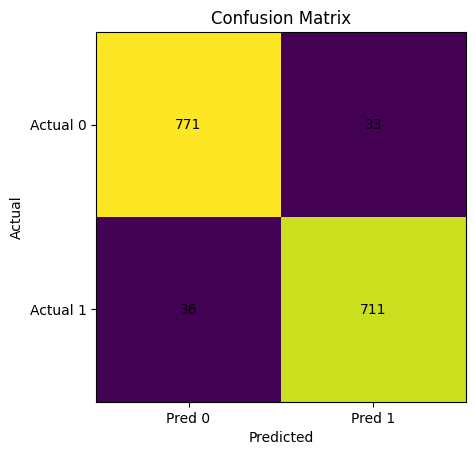

In [0]:
cm = (pred.groupBy("label", "prediction").count())
cm_matrix = (cm.groupBy("label").pivot("prediction").sum("count").orderBy("label"))
cm_pd = cm_matrix.toPandas()
matrix = cm_pd.iloc[:,1:].values
plt.imshow(matrix)
plt.xticks([0,1], ["Pred 0","Pred 1"])
plt.yticks([0,1], ["Actual 0","Actual 1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        plt.text(j, i, matrix[i, j], ha="center", va="center")
plt.show()

In [0]:
evaluator = MulticlassClassificationEvaluator(labelCol = "label", predictionCol = "prediction", metricName = "accuracy")
accuracy = evaluator.evaluate(pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9555125725338491
